In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('/content/amazonreviews.tsv', sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [9]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
df.shape

(10000, 2)

In [11]:
df.columns

Index(['label', 'review'], dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [13]:
df.isnull().sum()

,0
label,0
review,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['review'].duplicated().sum()

np.int64(0)

In [16]:
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


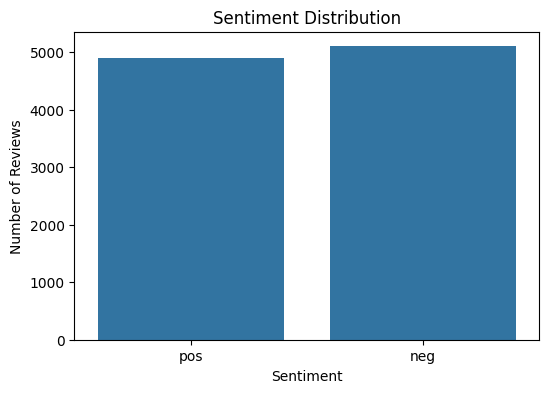

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=df)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [18]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)          # Remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)       # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()    # Remove extra spaces
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even for the non gamer this sound trac...
1,The best soundtrack ever to anything.: I'm rea...,the best soundtrack ever to anything i m readi...
2,Amazing!: This soundtrack is my favorite music...,amazing this soundtrack is my favorite music o...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack i truly like this soundtr...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull your jaw off the floor after hea...


In [19]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

df[['review', 'cleaned_review']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


In [20]:
positive_reviews = df[df['label'] == 'pos']['cleaned_review']
negative_reviews = df[df['label'] == 'neg']['cleaned_review']

print("Positive reviews:", len(positive_reviews))
print("Negative reviews:", len(negative_reviews))

Positive reviews: 4903
Negative reviews: 5097


In [21]:
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)

print("Positive text length:", len(positive_text))
print("Negative text length:", len(negative_text))

Positive text length: 1319197
Negative text length: 1404371


In [22]:
from wordcloud import WordCloud

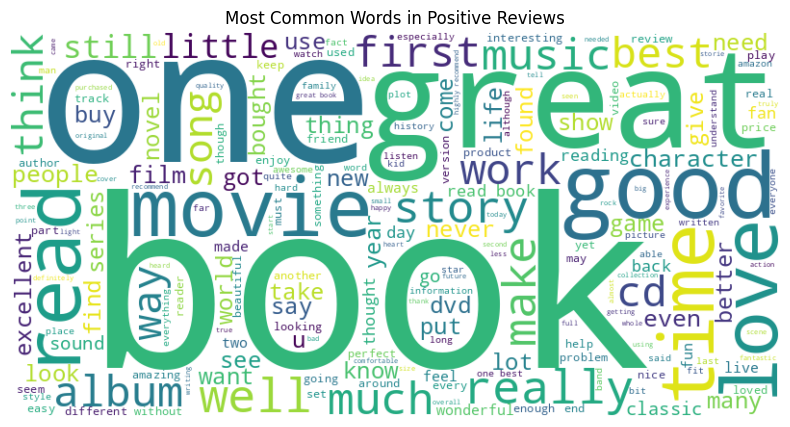

In [23]:
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

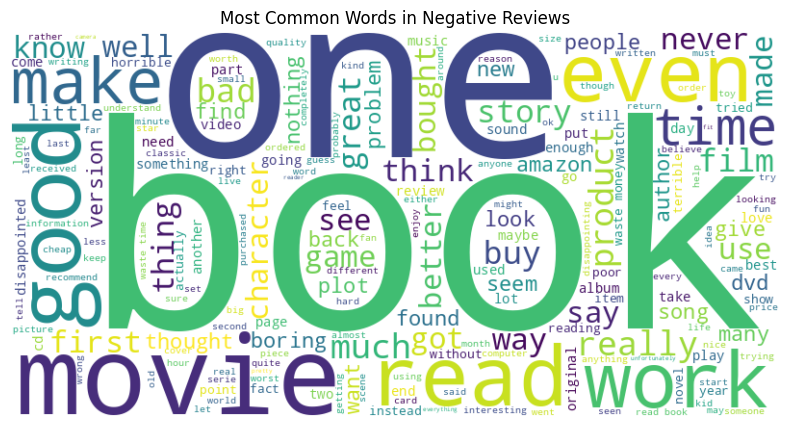

In [24]:
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [25]:
from collections import Counter

positive_words = positive_text.split()
negative_words = negative_text.split()

positive_common = Counter(positive_words).most_common(20)
negative_common = Counter(negative_words).most_common(20)

print("Top 20 Positive Words:")
print(positive_common)

print("\nTop 20 Negative Words:")
print(negative_common)

Top 20 Positive Words:
[('book', 3390), ('great', 2135), ('one', 1916), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1121), ('would', 956), ('well', 944), ('time', 924), ('love', 911), ('really', 832), ('best', 813), ('get', 805), ('story', 730), ('first', 724), ('much', 664), ('cd', 618), ('music', 577), ('also', 575)]

Top 20 Negative Words:
[('book', 3277), ('one', 2100), ('like', 1569), ('movie', 1519), ('would', 1465), ('read', 1222), ('good', 1160), ('get', 1151), ('time', 1072), ('even', 910), ('buy', 835), ('really', 783), ('much', 782), ('money', 767), ('bad', 764), ('first', 760), ('better', 677), ('could', 667), ('great', 644), ('story', 641)]


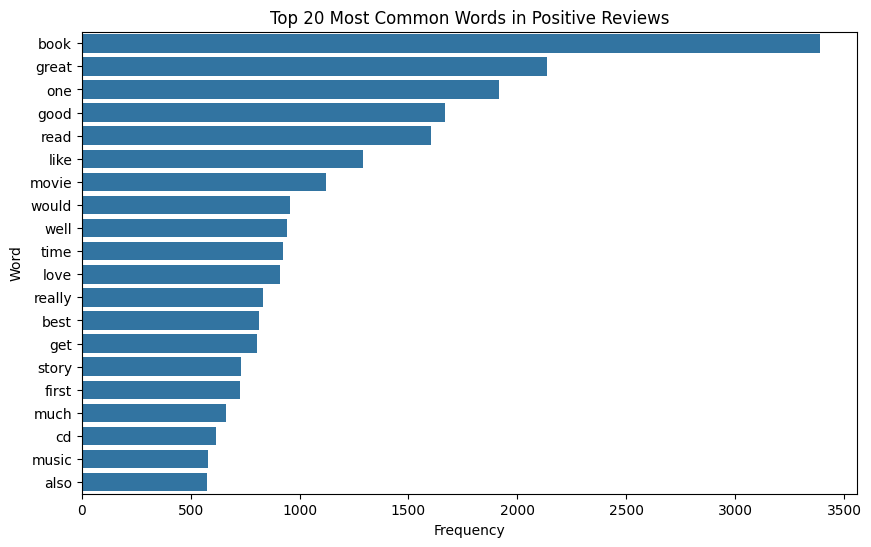

In [26]:
# Positive words
positive_df = pd.DataFrame(
    positive_common,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=positive_df,
    x='Frequency',
    y='Word'
)
plt.title('Top 20 Most Common Words in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

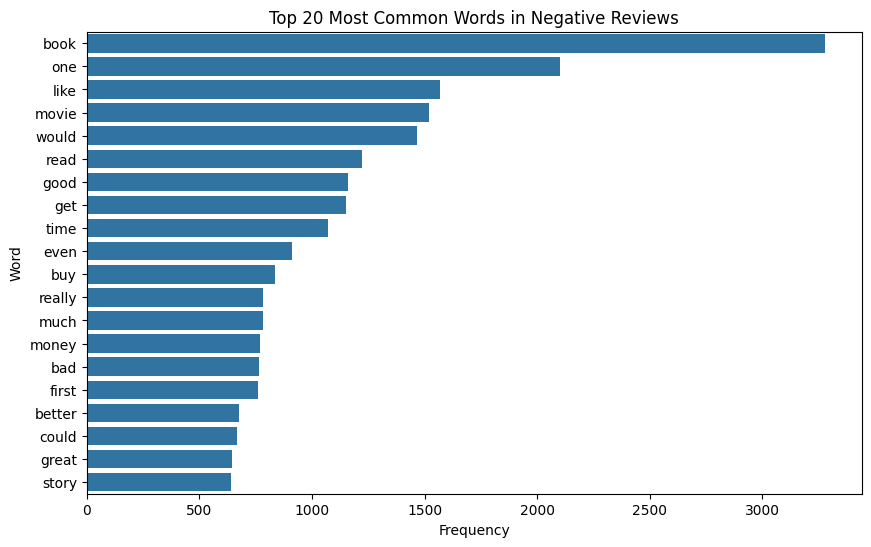

In [27]:
# Negative words
negative_df = pd.DataFrame(
    negative_common,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=negative_df,
    x='Frequency',
    y='Word'
)
plt.title('Top 20 Most Common Words in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['cleaned_review'])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (10000, 5000)


In [29]:
from sklearn.model_selection import train_test_split

X_text = df['cleaned_review']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 8000
Testing samples: 2000


In [30]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8000, 5000)
X_test shape: (2000, 5000)


In [31]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
y_pred = logistic_model.predict(X_test)

print(y_pred[:20])

['neg' 'pos' 'neg' 'pos' 'neg' 'neg' 'neg' 'pos' 'pos' 'pos' 'neg' 'neg'
 'neg' 'neg' 'pos' 'pos' 'neg' 'pos' 'neg' 'neg']


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='pos')
recall = recall_score(y_test, y_pred, pos_label='pos')
f1 = f1_score(y_test, y_pred, pos_label='pos')

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results
---------------------------
Accuracy : 0.854
Precision: 0.8526100307062436
Recall   : 0.8491335372069317
F1-Score : 0.8508682328907048

Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



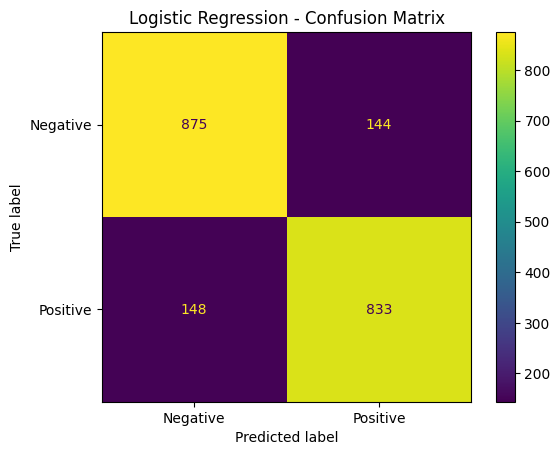

In [34]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=['neg', 'pos'])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
).plot()

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [35]:
#Cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation scores:
[0.86     0.861875 0.875625 0.86625  0.853125]

Mean CV Accuracy: 0.8633749999999999
Standard Deviation: 0.007443537465479692


In [36]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [37]:
y_svm_pred = svm_model.predict(X_test)

print(y_svm_pred[:20])

['neg' 'pos' 'neg' 'pos' 'neg' 'neg' 'neg' 'neg' 'pos' 'pos' 'pos' 'pos'
 'neg' 'neg' 'pos' 'pos' 'neg' 'pos' 'neg' 'neg']


In [38]:
svm_accuracy = accuracy_score(y_test, y_svm_pred)
svm_precision = precision_score(y_test, y_svm_pred, pos_label='pos')
svm_recall = recall_score(y_test, y_svm_pred, pos_label='pos')
svm_f1 = f1_score(y_test, y_svm_pred, pos_label='pos')

print("SVM Results")
print("-----------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-Score :", svm_f1)

SVM Results
-----------
Accuracy : 0.8465
Precision: 0.8431771894093686
Recall   : 0.8440366972477065
F1-Score : 0.8436067244014264


In [39]:
svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("SVM Cross-validation scores:")
print(svm_cv_scores)

print("\nMean SVM CV Accuracy:", svm_cv_scores.mean())
print("SVM CV Standard Deviation:", svm_cv_scores.std())

SVM Cross-validation scores:
[0.844375 0.8475   0.863125 0.855    0.838125]

Mean SVM CV Accuracy: 0.849625
SVM CV Standard Deviation: 0.008665665006218513


In [40]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        accuracy,
        precision,
        recall,
        f1
    ],
    'SVM': [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]
})

comparison

,Metric,Logistic Regression,SVM
0,Accuracy,0.854000,0.846500
1,Precision,0.852610,0.843177
2,Recall,0.849134,0.844037
3,F1-Score,0.850868,0.843607


In [41]:
print("Logistic Regression Mean CV Accuracy:", cv_scores.mean())
print("SVM Mean CV Accuracy:", svm_cv_scores.mean())

Logistic Regression Mean CV Accuracy: 0.8633749999999999
SVM Mean CV Accuracy: 0.849625


In [42]:
if svm_f1 > f1:
    best_model_name = "SVM"
    best_f1 = svm_f1
else:
    best_model_name = "Logistic Regression"
    best_f1 = f1

print("Best Model:", best_model_name)
print("Best F1-Score:", best_f1)

Best Model: Logistic Regression
Best F1-Score: 0.8508682328907048


In [43]:
if svm_accuracy > accuracy:
    print("SVM has the higher test accuracy.")
else:
    print("Logistic Regression has the higher test accuracy.")

Logistic Regression has the higher test accuracy.


In [44]:
print("Top 20 Positive Words")
print("---------------------")

for word, count in positive_common:
    print(f"{word}: {count}")

print("\nTop 20 Negative Words")
print("---------------------")

for word, count in negative_common:
    print(f"{word}: {count}")

Top 20 Positive Words
---------------------
book: 3390
great: 2135
one: 1916
good: 1667
read: 1605
like: 1290
movie: 1121
would: 956
well: 944
time: 924
love: 911
really: 832
best: 813
get: 805
story: 730
first: 724
much: 664
cd: 618
music: 577
also: 575

Top 20 Negative Words
---------------------
book: 3277
one: 2100
like: 1569
movie: 1519
would: 1465
read: 1222
good: 1160
get: 1151
time: 1072
even: 910
buy: 835
really: 783
much: 782
money: 767
bad: 764
first: 760
better: 677
could: 667
great: 644
story: 641


In [45]:
feature_names = np.array(tfidf.get_feature_names_out())

coefficients = logistic_model.coef_[0]

positive_indices = coefficients.argsort()[-20:][::-1]
negative_indices = coefficients.argsort()[:20]

print("Words strongly associated with Positive sentiment:")
print(feature_names[positive_indices])

print("\nWords strongly associated with Negative sentiment:")
print(feature_names[negative_indices])

Words strongly associated with Positive sentiment:
['great' 'excellent' 'love' 'best' 'perfect' 'good' 'wonderful' 'amazing'
 'easy' 'must' 'well' 'favorite' 'awesome' 'loves' 'loved' 'works'
 'highly' 'beautiful' 'one best' 'pleased']

Words strongly associated with Negative sentiment:
['boring' 'bad' 'waste' 'poor' 'disappointed' 'worst' 'disappointing'
 'money' 'horrible' 'terrible' 'nothing' 'disappointment' 'would' 'return'
 'maybe' 'idea' 'waste money' 'received' 'junk' 'buy']


In [46]:
if best_model_name == "SVM":
    best_predictions = y_svm_pred
else:
    best_predictions = y_pred

print("Best Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



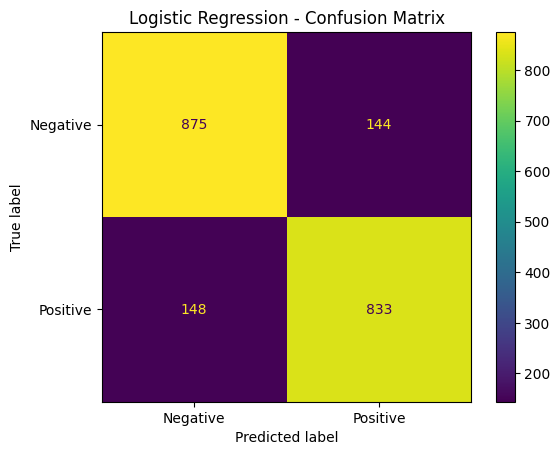

In [47]:
cm_best = confusion_matrix(
    y_test,
    best_predictions,
    labels=['neg', 'pos']
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=['Negative', 'Positive']
).plot()

plt.title(f'{best_model_name} - Confusion Matrix')
plt.show()

In [48]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Accuracy': [accuracy, svm_accuracy],
    'Precision': [precision, svm_precision],
    'Recall': [recall, svm_recall],
    'F1-Score': [f1, svm_f1],
    'Mean CV Accuracy': [cv_scores.mean(), svm_cv_scores.mean()]
})

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Mean CV Accuracy
0,Logistic Regression,0.8540,0.852610,0.849134,0.850868,0.863375
1,SVM,0.8465,0.843177,0.844037,0.843607,0.849625


In [49]:
print("FINAL MODEL COMPARISON")
print("=====================")
print(final_results.round(4))

FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score  \
0  Logistic Regression    0.8540     0.8526  0.8491    0.8509   
1                  SVM    0.8465     0.8432  0.8440    0.8436   

   Mean CV Accuracy  
0            0.8634  
1            0.8496  


Discussion

The objective of this project was to develop an automated sentiment analysis system capable of classifying Amazon customer reviews as either positive or negative. The dataset contained 10,000 customer reviews with two columns: label and review. The dataset was cleaned by checking for missing values and duplicate records, followed by text preprocessing including lowercasing, removal of HTML tags, punctuation, numbers, extra spaces, and stopwords.

Conclusion

The project successfully developed an NLP-based sentiment classification system for Amazon customer reviews. Text preprocessing and TF-IDF feature extraction transformed unstructured customer reviews into useful numerical representations for machine-learning models